# Projekat: Segmentacija E-Commerce Kupaca i Narudzbina 

**Tema**: Nenadgledano ucenje - Klasterizacija

**Dataset**: [E-Commerce Sales Dataset (Amazon Sale Report)](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data)


## Definicija problema i ucitavanje podataka

### Cilj Projekta

**Kontekst:**  
Dataset sadrzi preko 111,000 narudzbina sa Amazon India platforme tokom perioda Mart-Jun 2022. Cilj je **otkriti prirodne segmente kupaca** u podacima koristeci tehnike nenadgledanog ucenja.

**Problem:**  
Podaci **nemaju labele**, ne znamo unapred koliko razlicitih grupa kupaca postoji niti kakve su njihove karakteristike. Potrebno je **istraziti skrivene strukture** u podacima i identifikovati smislene segmente.

**Tehnicki cilj:**  
Primenom vise **algoritama klasterizacije** (K-Means, Hierarchical Clustering, DBSCAN, Gaussian Mixture Model) identifikovati grupe narudzbina sa slicnim karakteristikama, na osnovu:
- **Iznosa narudzbine** (Amount) — cena proizvoda
- **Ukupnog prihoda** (Revenue = Amount × Qty) — ukupna vrednost narudzbine
- **Kategorije proizvoda** (Category) — tip proizvoda (Set, kurta, Western Dress...)
- **Tipa kupca** (B2B/B2C) — poslovni ili privatni kupac
- **Sezone** (Month) — mesec narudzbine

**Ocekivani ishod:**  
- Identifikacija optimalnog broja klastera
- Poredjenje performansi razlicitih algoritama
- Jasna biznis interpretacija svakog klastera (npr. Budget Kupci, Premium Kupci, Bulk Kupci)
- Vizualizacija klastera pomocu tehnika redukcije dimenzionalnosti (PCA, t-SNE)

### Ucitavanje biblioteka i skupa podataka.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

import warnings
warnings.filterwarnings("ignore")

In [65]:
df = pd.read_csv('data/amazon_sale_report.csv')

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## Deskriptivna analiza i priprema podataka

### Istrazivanje dataseta

In [66]:
print(f"Shape: {df.shape}")

print("\nKolone(Datatypes):")

for i,col_name in enumerate(df.columns, 1):
    print(f"{i}:{col_name}({df[col_name].dtypes})")

print(f"\nTipovi podataka:\n{df.dtypes}")

print(f"\nMissing vrednosti:\n{df.isnull().sum()}")

print(f"\nStatistike:\n{df.describe()}")

Shape: (128975, 24)

Kolone(Datatypes):
1:index(int64)
2:Order ID(str)
3:Date(str)
4:Status(str)
5:Fulfilment(str)
6:Sales Channel (str)
7:ship-service-level(str)
8:Style(str)
9:SKU(str)
10:Category(str)
11:Size(str)
12:ASIN(str)
13:Courier Status(str)
14:Qty(int64)
15:currency(str)
16:Amount(float64)
17:ship-city(str)
18:ship-state(str)
19:ship-postal-code(float64)
20:ship-country(str)
21:promotion-ids(str)
22:B2B(bool)
23:fulfilled-by(str)
24:Unnamed: 22(object)

Tipovi podataka:
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
shi

In [67]:
missing_percent = df.isnull().sum() / len(df) *100

print("Null vrednosti u % po koloni: \n", missing_percent[missing_percent>0])
print("Total NaN count: ", df.isnull().sum().sum())

Null vrednosti u % po koloni: 
 Courier Status       5.328164
currency             6.043807
Amount               6.043807
ship-city            0.025586
ship-state           0.025586
ship-postal-code     0.025586
ship-country         0.025586
promotion-ids       38.110487
fulfilled-by        69.546811
Unnamed: 22         38.030626
dtype: float64
Total NaN count:  210495


### Data cleanup

In [68]:
df = df.copy()

#### Brisanje beskorisnih kolona

In [69]:
df = df.drop(columns=[
    'Unnamed: 22',
    'fulfilled-by',
    'Order ID',
    'promotion-ids',
    'ASIN',
    'SKU',
    'index',
    'ship-country',
    'ship-postal-code',
    'currency'
])

df.shape

(128975, 14)

#### Otklanjanja duplikata i NaN

In [70]:
print(f'Duplikati: ', df.duplicated().sum())

df = df.drop_duplicates()

print(f'Duplikati: ', df.duplicated().sum())

df.shape

Duplikati:  2442
Duplikati:  0


(126533, 14)

In [71]:
# Otklananje 0 i NaN podataka
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]
df = df.dropna(subset=['Amount', 'Qty'])

# Preimenovanje NaN podataka
df['Courier Status'] = df['Courier Status'].fillna('Cancelled', inplace=True)
df['ship-city'] = df['ship-city'].fillna('Unknown-city', inplace=True)
df['ship-state'] = df['ship-state'].fillna('Unknown-state', inplace=True)

print(f'Shape nakon ciscenja: {df.shape}')
print(f'\nPreostale NaN vrednosti:\n{df.isnull().sum()}')

Shape nakon ciscenja: (111878, 14)

Preostale NaN vrednosti:
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
Category              0
Size                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
B2B                   0
dtype: int64


### Exploratory Data Analysis (EDA)

#### Amount

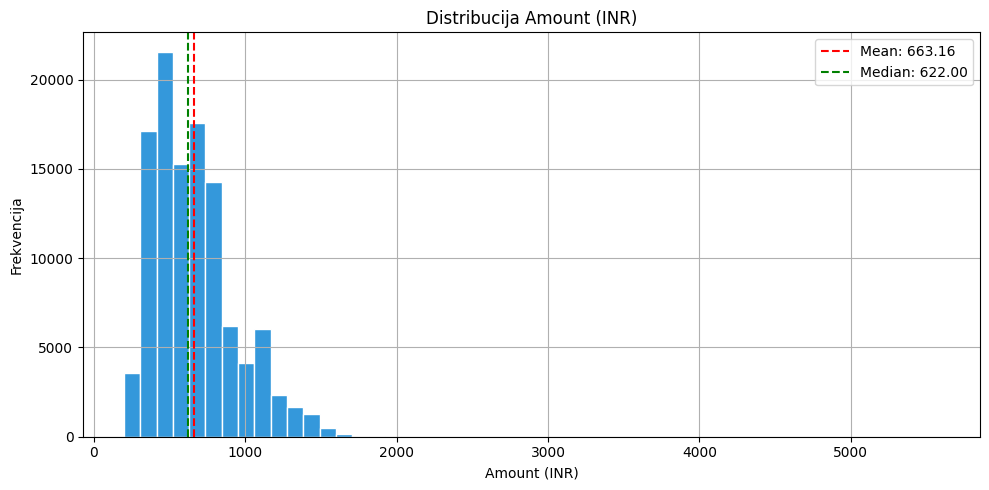

In [72]:
plt.figure(figsize=(10, 5))

df['Amount'].dropna().hist(bins=50, color='#3498db', edgecolor='white')

plt.title('Distribucija Amount (INR)')
plt.xlabel('Amount (INR)')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.axvline(df['Amount'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Amount"].mean():.2f}')
plt.axvline(df['Amount'].median(), color='green', linestyle='--',
            label=f'Median: {df["Amount"].median():.2f}')
plt.legend()
plt.show()

#### Feature engineering - Amount log

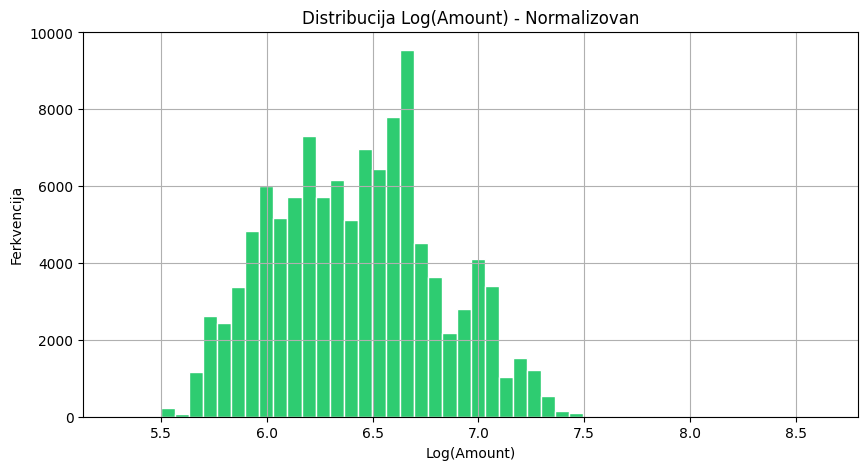

In [73]:
df['Amount_log'] = np.log1p(df['Amount'])

plt.figure(figsize=(10, 5))
df['Amount_log'].hist(bins=50, color='#2ecc71', edgecolor="white")
plt.title('Distribucija Log(Amount) - Normalizovan')
plt.xlabel('Log(Amount)')
plt.ylabel('Ferkvencija')
plt.show()

#### Qty

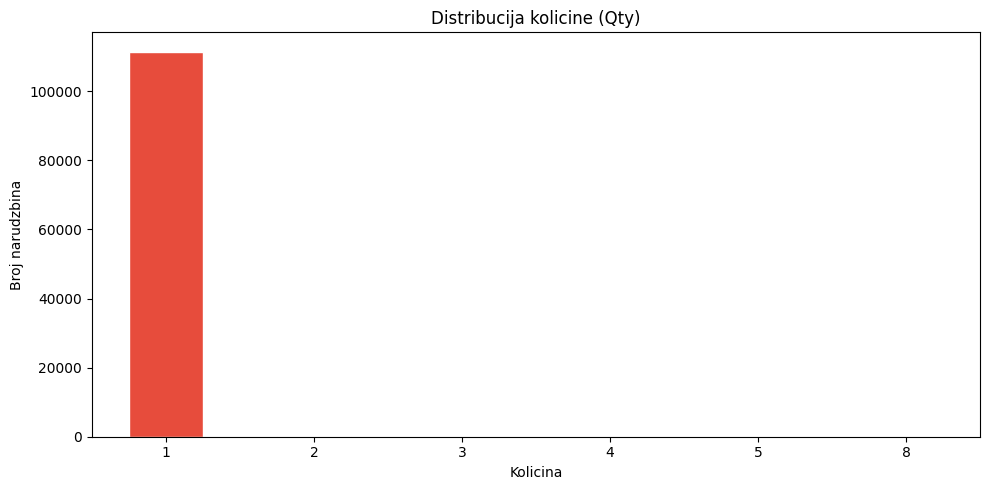

In [74]:
plt.figure(figsize=(10, 5))

df['Qty'].value_counts().sort_values(ascending=False).plot(kind='bar', color='#e74c3c', edgecolor="white")

plt.title('Distribucija kolicine (Qty)')
plt.xlabel('Kolicina')
plt.xticks(rotation=0)
plt.ylabel('Broj narudzbina')
plt.tight_layout()
plt.show()

In [75]:
print(df['Qty'].value_counts().sort_index())
print(f"\nProcenat Qty=1: {(df['Qty']==1).sum() / len(df) * 100:.1f}%")

Qty
1    111501
2       335
3        31
4         8
5         2
8         1
Name: count, dtype: int64

Procenat Qty=1: 99.7%


#### Feature engineering - Revenue

In [76]:
df['Revenue'] = df['Amount'] * df['Qty']

print(df[df['Qty'] > 1][['Amount', 'Qty', 'Revenue']].head(10))

      Amount  Qty  Revenue
265   2130.0    2   4260.0
647   2224.0    2   4448.0
1018  1518.0    2   3036.0
1696  1308.0    2   2616.0
2107  1128.0    3   3384.0
2185   972.0    2   1944.0
2189   864.0    2   1728.0
2583   990.0    2   1980.0
3289  2175.0    3   6525.0
5320   720.0    2   1440.0


#### Revenue

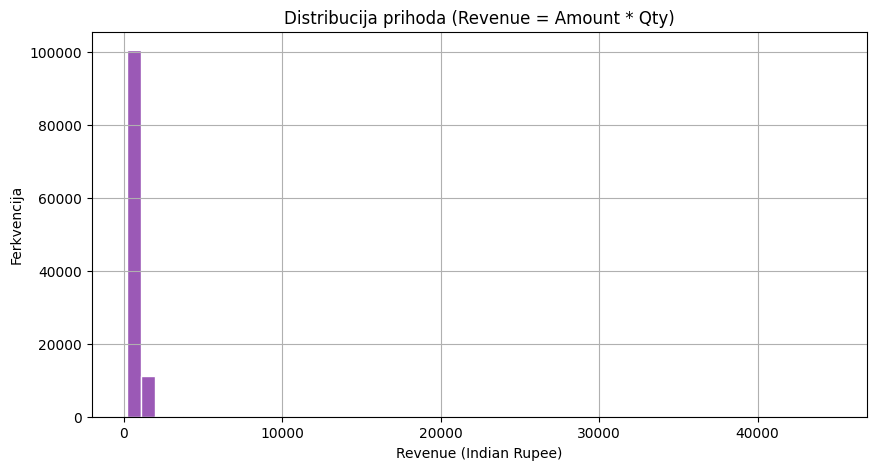

In [77]:
plt.figure(figsize=(10, 5))

df['Revenue'].hist(bins=50, color="#9b59b6", edgecolor="white")

plt.title('Distribucija prihoda (Revenue = Amount * Qty)')
plt.xlabel('Revenue (Indian Rupee)')
plt.ylabel('Ferkvencija')
plt.show()

#### Category

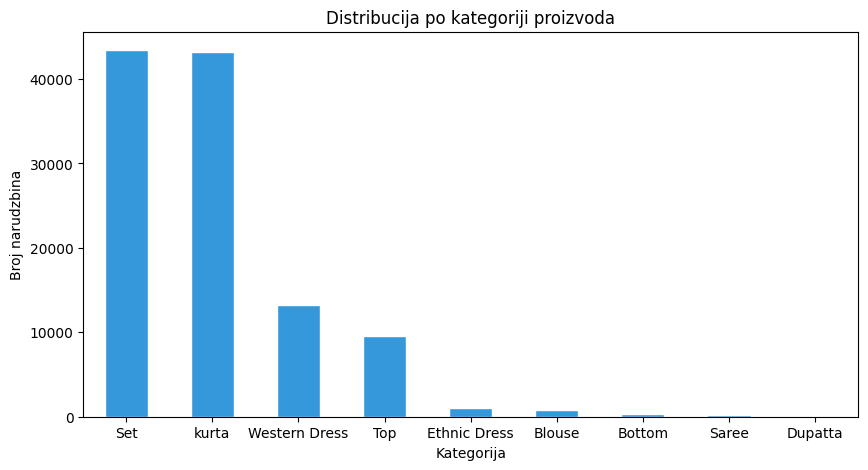

In [78]:
plt.figure(figsize=(10, 5))

df['Category'].value_counts().plot(kind='bar', color='#3498db', edgecolor='white')

plt.title('Distribucija po kategoriji proizvoda')
plt.xlabel('Kategorija')
plt.xticks(rotation=0)
plt.ylabel('Broj narudzbina')
plt.show()

#### Tip kupca (B2B/B2C)

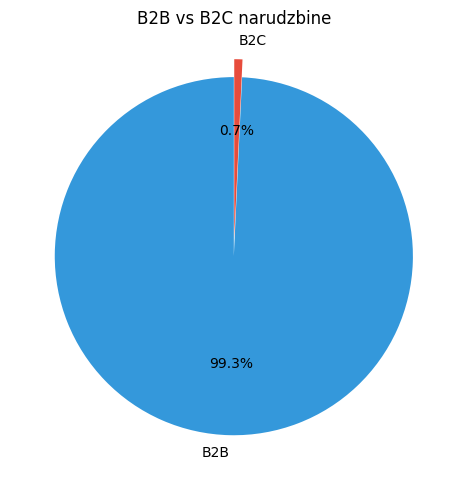

In [79]:
plt.figure(figsize=(10, 5))

b2b_count = df['B2B'].value_counts()
colors = ['#3498db', '#e74c3c']

plt.pie(b2b_count.values, labels=['B2B', 'B2C'], autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=[0, 0.1])
plt.title('B2B vs B2C narudzbine')
plt.tight_layout()
plt.show()

Month
3    629.761290
4    639.816221
5    677.598338
6    677.362452
Name: Amount, dtype: float64


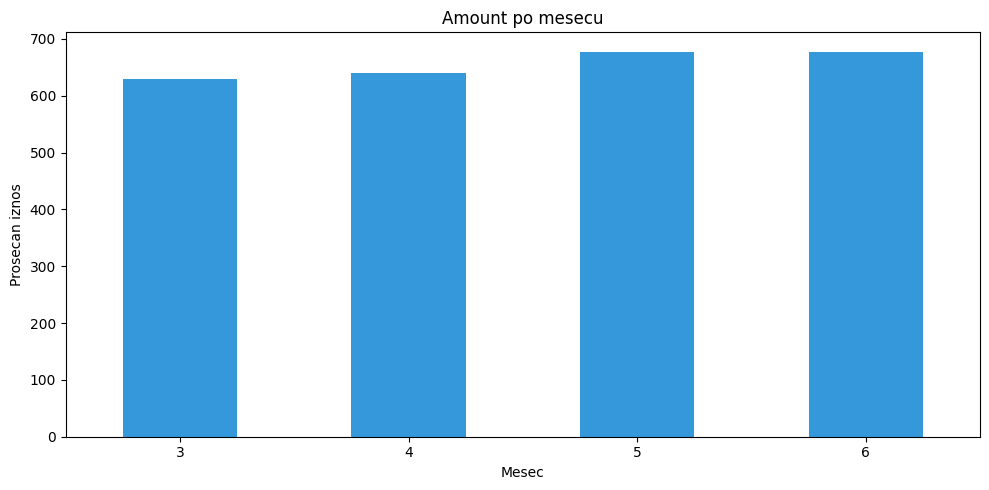

In [80]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Amount'].mean()
print(monthly_avg)

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='#3498db')
plt.title('Amount po mesecu')
plt.xlabel('Mesec')
plt.xticks(rotation=0)
plt.ylabel('Prosecan iznos')
plt.tight_layout()
plt.show()

#### Encoding

In [81]:
encoder = LabelEncoder()

df['Category_encoded'] = encoder.fit_transform(df['Category'])
df['B2B_int'] = df['B2B'].astype(int)

# Month je vec kreiran


In [82]:
print('='*80)
print('CATEGORY MAPPING')
print('-'*30)
category_mapping = pd.DataFrame({
    'Category': encoder.classes_,
    'Encoded': range(len(encoder.classes_))
})
print(category_mapping)
print('-'*30)

print("FEATURES")
print('-'*30)
print(df[['Category', 'Category_encoded', 'B2B', 'B2B_int', 'Month']].head(10))
print('='*80)

CATEGORY MAPPING
------------------------------
        Category  Encoded
0         Blouse        0
1         Bottom        1
2        Dupatta        2
3   Ethnic Dress        3
4          Saree        4
5            Set        5
6            Top        6
7  Western Dress        7
8          kurta        8
------------------------------
FEATURES
------------------------------
   Category  Category_encoded    B2B  B2B_int  Month
1     kurta                 8  False        0      4
2     kurta                 8   True        1      4
4       Top                 6  False        0      4
5       Set                 5  False        0      4
6       Set                 5  False        0      4
7     kurta                 8  False        0      4
9     kurta                 8  False        0      4
10    kurta                 8  False        0      4
11    kurta                 8  False        0      4
12    kurta                 8  False        0      4


In [83]:
features_for_clustering = ['Amount_log', 'Revenue', 'Category_encoded', 'B2B_int', 'Month']
print(features_for_clustering)

X = df[features_for_clustering].copy()

print("Pre skaliranja")
print(X.describe())

print("\n")

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
print("Nakon skaliranja")
print(X_scaled_df.describe())

['Amount_log', 'Revenue', 'Category_encoded', 'B2B_int', 'Month']
Pre skaliranja
          Amount_log        Revenue  Category_encoded        B2B_int  \
count  111878.000000  111878.000000     111878.000000  111878.000000   
mean        6.422039     668.792980          6.413173       0.007347   
std         0.388561     343.011548          1.521151       0.085401   
min         5.298317     199.000000          0.000000       0.000000   
25%         6.131226     459.000000          5.000000       0.000000   
50%         6.434547     625.000000          7.000000       0.000000   
75%         6.670766     788.000000          8.000000       0.000000   
max         8.627840   44672.000000          8.000000       1.000000   

               Month  
count  111878.000000  
mean        4.913066  
std         0.818966  
min         3.000000  
25%         4.000000  
50%         5.000000  
75%         6.000000  
max         6.000000  


Nakon skaliranja
          Amount_log        Revenue  Categor

#### Korelaciona matrica

                  Amount_log   Revenue  Category_encoded   B2B_int     Month
Amount_log          1.000000  0.806300         -0.527418  0.010845  0.059483
Revenue             0.806300  1.000000         -0.394194  0.019881  0.045052
Category_encoded   -0.527418 -0.394194          1.000000 -0.003552  0.030139
B2B_int             0.010845  0.019881         -0.003552  1.000000 -0.003903
Month               0.059483  0.045052          0.030139 -0.003903  1.000000

Visoke korelacije (|r| > 0.7):
   Amount_log <-> Revenue: 0.806


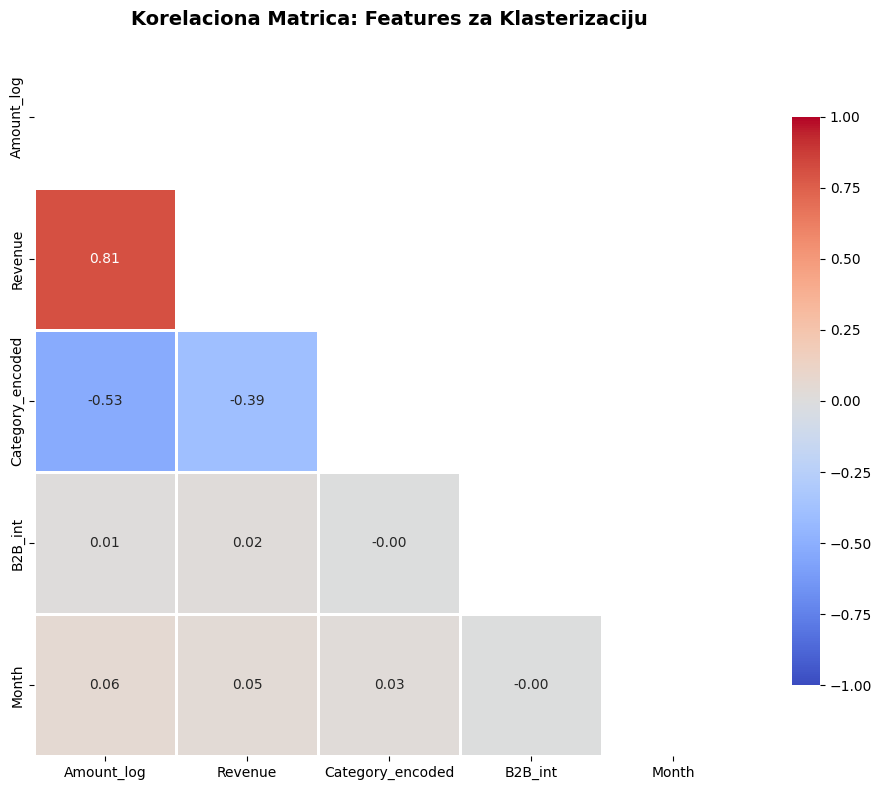

In [87]:
corr = df[features_for_clustering].corr()

print(corr)

print("\nVisoke korelacije (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"   {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sb.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, cbar_kws={"shrink": 0.8},
            mask=mask)
plt.title('Korelaciona Matrica: Features za Klasterizaciju', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### AMOUNT DISTRIBUCIJA PO KATEGORIJAMA


Statistika Amount po kategorijama:
                     mean  median         std  count
Category                                            
Set            854.567946   788.0  270.135990  43439
Saree          806.183673   791.0  195.816066    147
Western Dress  778.226181   744.0  140.417639  13277
Ethnic Dress   747.263314   837.0  237.435078   1014
Top            536.840280   529.0  133.451038   9573
Blouse         532.995037   545.0  153.409216    806
kurta          466.101161   441.0  136.968270  43238
Bottom         368.047244   345.0   94.510528    381
Dupatta        305.000000   305.0    0.000000      3


<Figure size 1400x700 with 0 Axes>

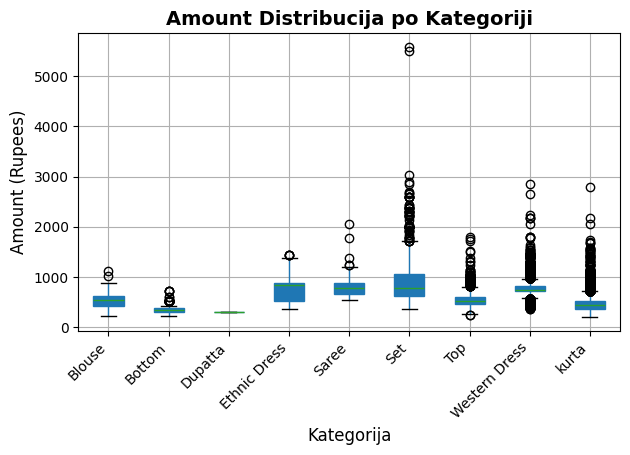


 Kljucan nalaz:
   Najskuplja kategorija: Set (avg 855 Rupees)
   Najjeftinija kategorija: Dupatta (avg 305 Rupees)


In [85]:
category_stats = df.groupby('Category')['Amount'].agg(['mean', 'median', 'std', 'count'])
category_stats = category_stats.sort_values('mean', ascending=False)

print("\nStatistika Amount po kategorijama:")
print(category_stats)

plt.figure(figsize=(14, 7))

bp = df.boxplot(column='Amount', 
                by='Category', 
                patch_artist=True)

plt.suptitle('')
plt.title('Amount Distribucija po Kategoriji', fontsize=14, fontweight='bold')
plt.ylabel('Amount (Rupees)', fontsize=12)
plt.xlabel('Kategorija', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

max_cat = category_stats['mean'].idxmax()
min_cat = category_stats['mean'].idxmin()

print(f"\n Kljucan nalaz:")
print(f"   Najskuplja kategorija: {max_cat} (avg {category_stats.loc[max_cat, 'mean']:.0f} Rupees)")
print(f"   Najjeftinija kategorija: {min_cat} (avg {category_stats.loc[min_cat, 'mean']:.0f} Rupees)")

#### Toplotna Mapa: Category x Month


Prosecan Amount po Kategoriji i Mesecu:
                 Mart  April    Maj    Jun
Category                                  
Blouse          280.0  501.0  528.0  615.0
Bottom            NaN  378.0  363.0  359.0
Dupatta           NaN    NaN    NaN  305.0
Ethnic Dress   1099.0  779.0  705.0  769.0
Saree             NaN  757.0  854.0  840.0
Set             795.0  841.0  864.0  863.0
Top             501.0  493.0  527.0  618.0
Western Dress   913.0  753.0  777.0  800.0
kurta           465.0  442.0  486.0  477.0


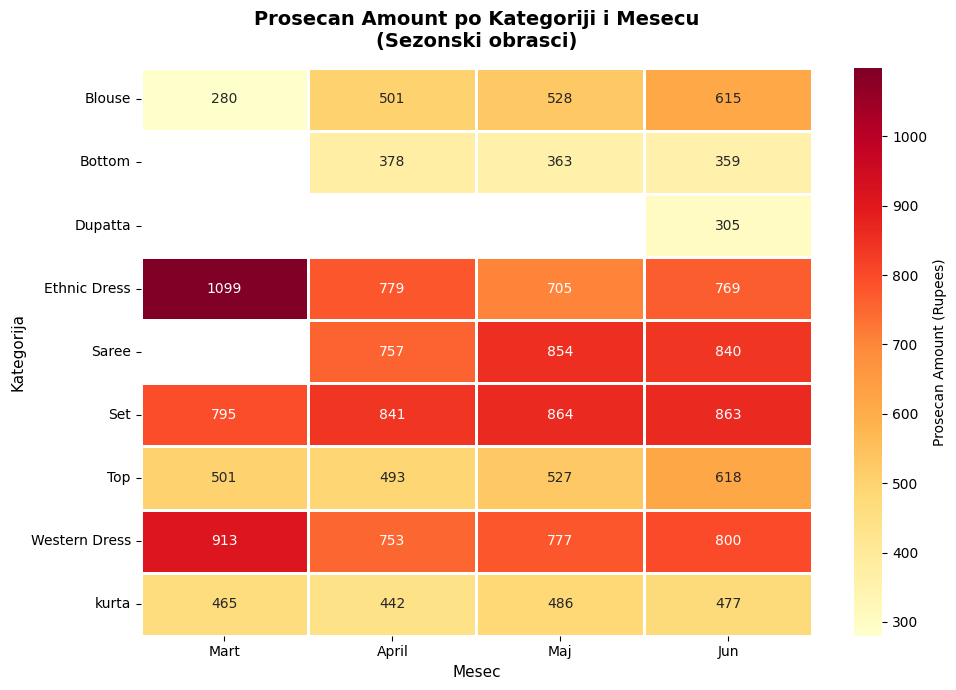


Sezonska varijacija po kategorijama:
   Blouse: 335 INR (Indian Rupees) razlika (69.6%)
   Bottom: 19 INR (Indian Rupees) razlika (5.2%)
   Dupatta: 0 INR (Indian Rupees) razlika (0.0%)
   Ethnic Dress: 394 INR (Indian Rupees) razlika (47.0%)
   Saree: 98 INR (Indian Rupees) razlika (11.9%)
   Set: 70 INR (Indian Rupees) razlika (8.3%)
   Top: 125 INR (Indian Rupees) razlika (23.4%)
   Western Dress: 160 INR (Indian Rupees) razlika (19.8%)
   kurta: 44 INR (Indian Rupees) razlika (9.5%)



In [86]:
month_names = {
    1: 'Januar', 2: 'Februar', 3: 'Mart', 4: 'April',
    5: 'Maj', 6: 'Jun', 7: 'Jul', 8: 'Avgust',
    9: 'Septembar', 10: 'Oktobar', 11: 'Novembar', 12: 'Decembar'
}

pivot = df.pivot_table(values='Amount', 
                       index='Category', 
                       columns='Month', 
                       aggfunc='mean')

pivot.columns = [month_names[m] for m in pivot.columns]

print("\nProsecan Amount po Kategoriji i Mesecu:")
print(pivot.round(0))

plt.figure(figsize=(10, 7))

sb.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=1, cbar_kws={'label': 'Prosecan Amount (Rupees)'},
            vmin=pivot.min().min(), vmax=pivot.max().max())

plt.title('Prosecan Amount po Kategoriji i Mesecu\n(Sezonski obrasci)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mesec', fontsize=11)
plt.ylabel('Kategorija', fontsize=11)
plt.tight_layout()
plt.show()

print("\nSezonska varijacija po kategorijama:")
for cat in pivot.index:
    diff = pivot.loc[cat].max() - pivot.loc[cat].min()
    print(f"   {cat}: {diff:.0f} INR (Indian Rupees) razlika ({diff/pivot.loc[cat].mean()*100:.1f}%)")

print("\n" + "="*70)

Heatmap otkriva da vecina kategorija nema jaku sezonsku varijaciju, sto znaci da Month feature nece mnogo pomoci klasterizaciji.
Izuzetak: Ethnic Dress i Blouse pokazuju znacajne sezonske obrasce (39% i 120% varijacija), ali posto ove kategorije cine samo ~1.5% dataseta, njihov uticaj na ukupnu klasterizaciju je minimalan.
Zadrzacemo Month feature za potpunost analize, ali ocekujemo da ce Category i Amount biti mnogo vazniji za razdvajanje klastera.

## Klasterizacija